<a href="https://colab.research.google.com/github/minjilee-purdue/erc_tree_semantic_segmentation_in_mlops/blob/main/vit_patch_vis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from PIL import Image
import requests
from io import BytesIO
import matplotlib.gridspec as gridspec

# Load sample image
url = 'https://raw.githubusercontent.com/minjilee-purdue/erc_tree_semantic_segmentation_in_mlops/main/sample_image.png'
response = requests.get(url)
img = Image.open(BytesIO(response.content)).convert('RGB')
img = img.resize((224, 224))
img_array = np.array(img)
print(f'Image shape: {img_array.shape}')  # (224, 224, 3)

Image shape: (224, 224, 3)


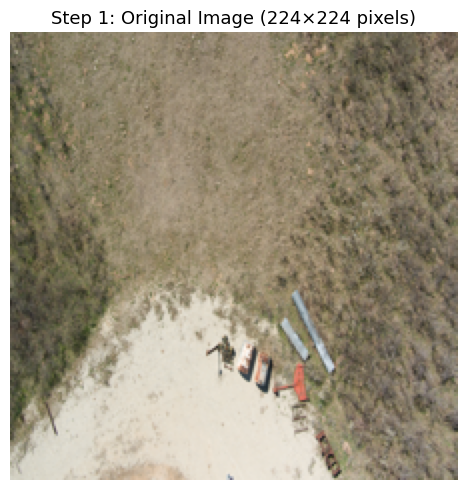

In [2]:
plt.figure(figsize=(5, 5))
plt.imshow(img_array)
plt.title('Step 1: Original Image (224×224 pixels)', fontsize=13)
plt.axis('off')
plt.tight_layout()
plt.show()

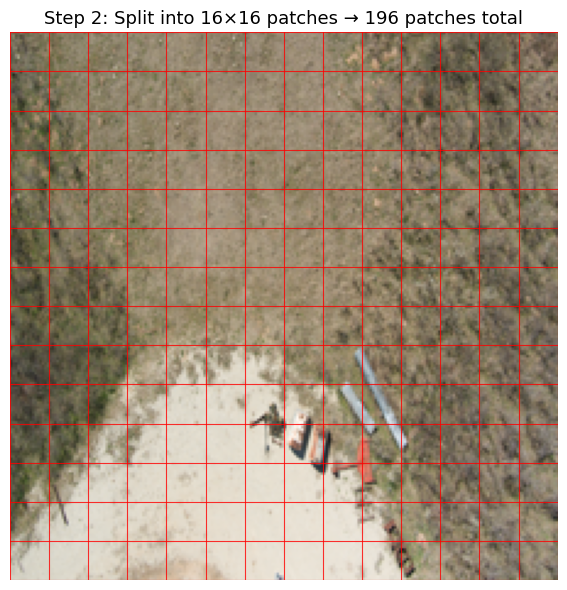

Patch size: 16×16 pixels
Total patches: 14×14 = 196


In [3]:
PATCH_SIZE = 16
IMG_SIZE = 224
num_patches_per_side = IMG_SIZE // PATCH_SIZE  # 14
num_patches = num_patches_per_side ** 2         # 196

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.imshow(img_array)

for i in range(0, IMG_SIZE + 1, PATCH_SIZE):
    ax.axhline(i - 0.5, color='red', linewidth=0.8, alpha=0.8)
    ax.axvline(i - 0.5, color='red', linewidth=0.8, alpha=0.8)

ax.set_title(f'Step 2: Split into 16×16 patches → {num_patches} patches total', fontsize=13)
ax.axis('off')
plt.tight_layout()
plt.show()
print(f'Patch size: {PATCH_SIZE}×{PATCH_SIZE} pixels')
print(f'Total patches: {num_patches_per_side}×{num_patches_per_side} = {num_patches}')

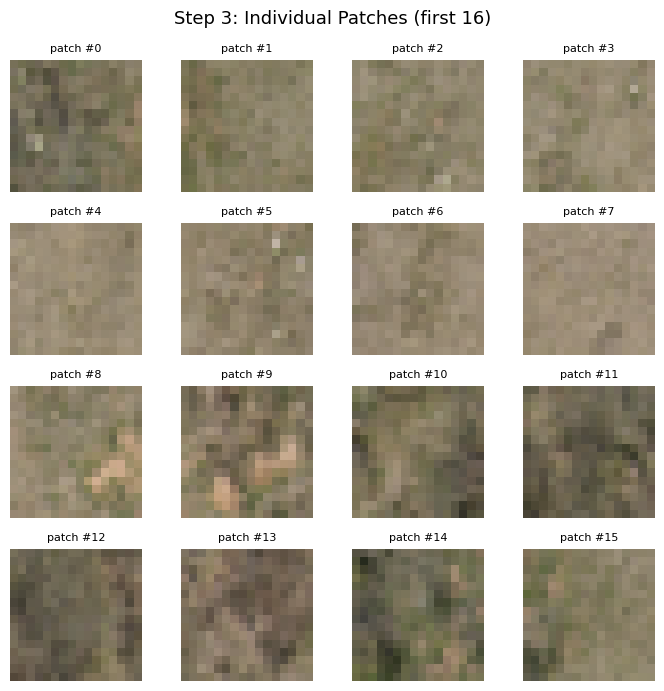

Single patch shape: (16, 16, 3)  (16×16 pixels × 3 RGB channels)


In [4]:
def extract_patches(image, patch_size=16):
    h, w, c = image.shape
    patches = []
    for row in range(0, h, patch_size):
        for col in range(0, w, patch_size):
            patch = image[row:row+patch_size, col:col+patch_size, :]
            patches.append(patch)
    return patches

patches = extract_patches(img_array)

fig, axes = plt.subplots(4, 4, figsize=(7, 7))
fig.suptitle('Step 3: Individual Patches (first 16)', fontsize=13)
for idx, ax in enumerate(axes.flatten()):
    ax.imshow(patches[idx])
    ax.set_title(f'patch #{idx}', fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.show()
print(f'Single patch shape: {patches[0].shape}  (16×16 pixels × 3 RGB channels)')

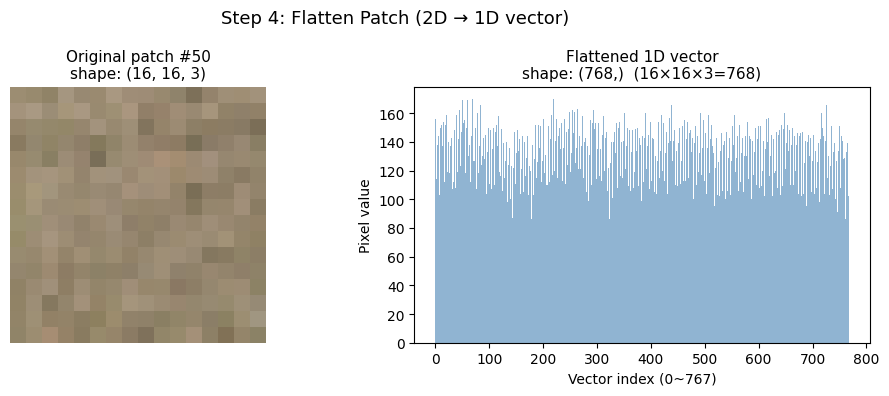

In [5]:
patch_example = patches[50]
flat_patch = patch_example.flatten()  # 16×16×3 = 768

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('Step 4: Flatten Patch (2D → 1D vector)', fontsize=13)

axes[0].imshow(patch_example)
axes[0].set_title(f'Original patch #50\nshape: {patch_example.shape}', fontsize=11)
axes[0].axis('off')

axes[1].bar(range(len(flat_patch)), flat_patch, color='steelblue', alpha=0.6, width=1.0)
axes[1].set_title(f'Flattened 1D vector\nshape: {flat_patch.shape}  (16×16×3=768)', fontsize=11)
axes[1].set_xlabel('Vector index (0~767)')
axes[1].set_ylabel('Pixel value')

plt.tight_layout()
plt.show()

Patch tensor shape: torch.Size([196, 768])  → (num_patches, flattened_size)
Token tensor shape: torch.Size([196, 768])  → (num_patches, token_dim)


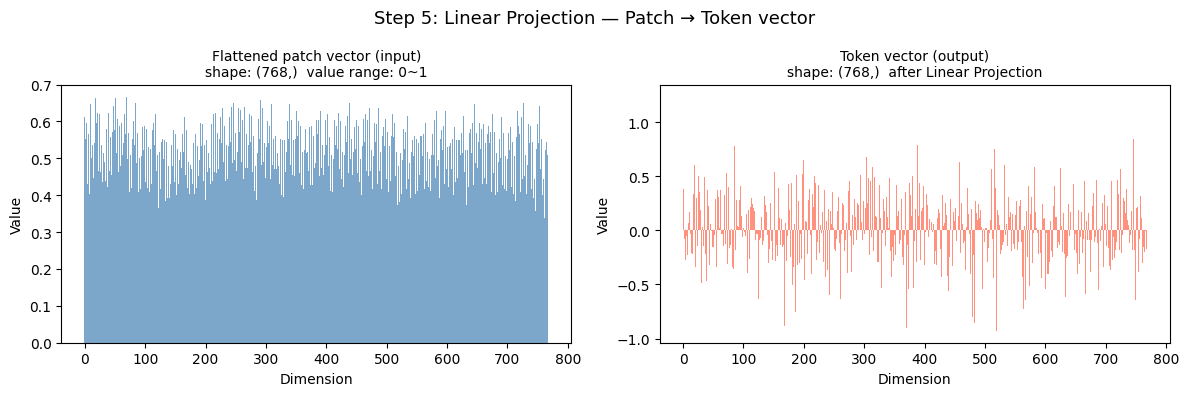

In [6]:
D_MODEL = 768
linear_proj = nn.Linear(PATCH_SIZE * PATCH_SIZE * 3, D_MODEL)

patches_np = np.array([p.flatten() for p in patches], dtype=np.float32) / 255.0
patches_tensor = torch.tensor(patches_np)  # (196, 768)

with torch.no_grad():
    tokens = linear_proj(patches_tensor)  # (196, 768)

print(f'Patch tensor shape: {patches_tensor.shape}  → (num_patches, flattened_size)')
print(f'Token tensor shape: {tokens.shape}  → (num_patches, token_dim)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Step 5: Linear Projection — Patch → Token vector', fontsize=13)

axes[0].bar(range(768), patches_np[50], color='steelblue', alpha=0.7, width=1.0)
axes[0].set_title('Flattened patch vector (input)\nshape: (768,)  value range: 0~1', fontsize=10)
axes[0].set_xlabel('Dimension')
axes[0].set_ylabel('Value')

axes[1].bar(range(D_MODEL), tokens[50].numpy(), color='tomato', alpha=0.7, width=1.0)
axes[1].set_title(f'Token vector (output)\nshape: ({D_MODEL},)  after Linear Projection', fontsize=10)
axes[1].set_xlabel('Dimension')
axes[1].set_ylabel('Value')

plt.tight_layout()
plt.show()

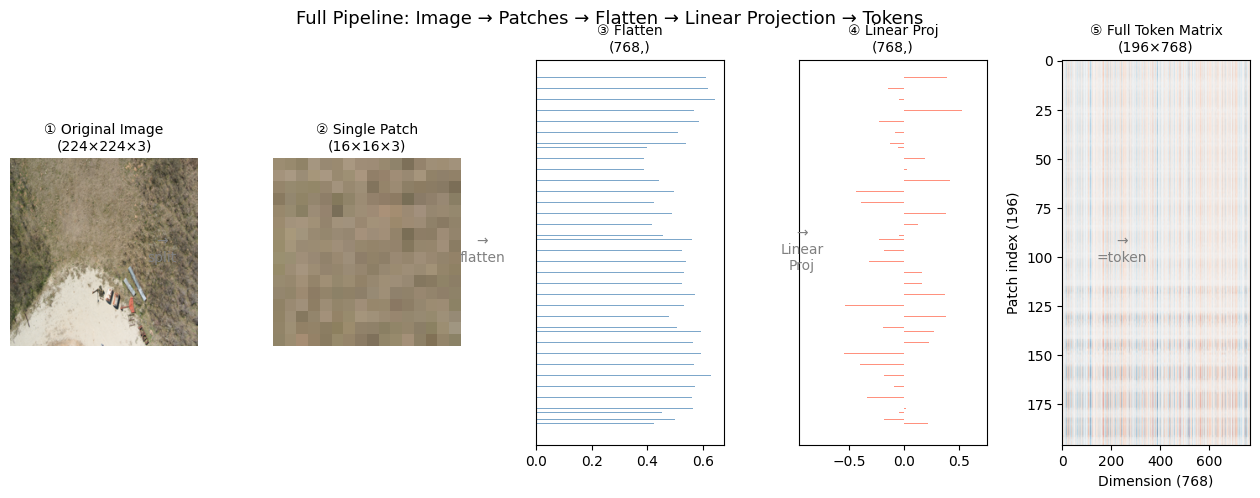


Each row = 1 token = 1 patch


In [7]:
fig = plt.figure(figsize=(16, 5))
gs = gridspec.GridSpec(1, 5, figure=fig, wspace=0.4)
fig.suptitle('Full Pipeline: Image → Patches → Flatten → Linear Projection → Tokens', fontsize=13)

ax1 = fig.add_subplot(gs[0])
ax1.imshow(img_array)
ax1.set_title('① Original Image\n(224×224×3)', fontsize=10)
ax1.axis('off')

for pos, label in [(0.22, 'split'), (0.42, 'flatten'), (0.62, 'Linear\nProj'), (0.82, '=token')]:
    fig.text(pos, 0.5, f'→\n{label}', ha='center', va='center', fontsize=10, color='gray')

ax2 = fig.add_subplot(gs[1])
ax2.imshow(patches[50])
ax2.set_title('② Single Patch\n(16×16×3)', fontsize=10)
ax2.axis('off')

ax3 = fig.add_subplot(gs[2])
ax3.barh(range(0, 768, 8), patches_np[50][::8], color='steelblue', alpha=0.7)
ax3.set_title('③ Flatten\n(768,)', fontsize=10)
ax3.set_yticks([])
ax3.invert_yaxis()

ax4 = fig.add_subplot(gs[3])
ax4.barh(range(0, 768, 8), tokens[50].numpy()[::8], color='tomato', alpha=0.7)
ax4.set_title('④ Linear Proj\n(768,)', fontsize=10)
ax4.set_yticks([])
ax4.invert_yaxis()

ax5 = fig.add_subplot(gs[4])
ax5.imshow(tokens.numpy(), aspect='auto', cmap='RdBu', vmin=-2, vmax=2)
ax5.set_title(f'⑤ Full Token Matrix\n(196×768)', fontsize=10)
ax5.set_xlabel('Dimension (768)')
ax5.set_ylabel('Patch index (196)')

plt.show()
print('\nEach row = 1 token = 1 patch')

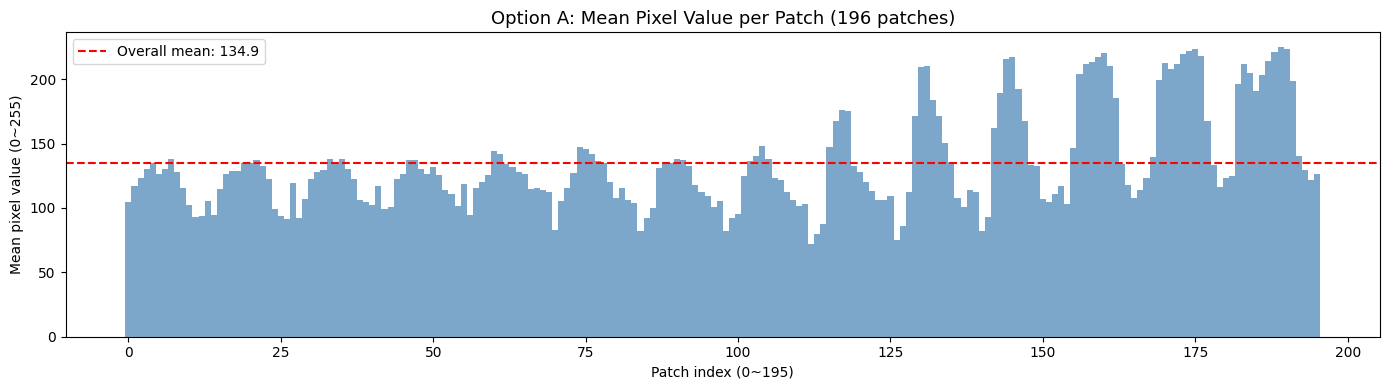

In [8]:
# Option A: Mean brightness per patch
patch_means = [np.mean(p) for p in patches]

plt.figure(figsize=(14, 4))
plt.bar(range(len(patch_means)), patch_means, color='steelblue', alpha=0.7, width=1.0)
plt.title('Option A: Mean Pixel Value per Patch (196 patches)', fontsize=13)
plt.xlabel('Patch index (0~195)')
plt.ylabel('Mean pixel value (0~255)')
plt.axhline(np.mean(patch_means), color='red', linestyle='--', label=f'Overall mean: {np.mean(patch_means):.1f}')
plt.legend()
plt.tight_layout()
plt.show()

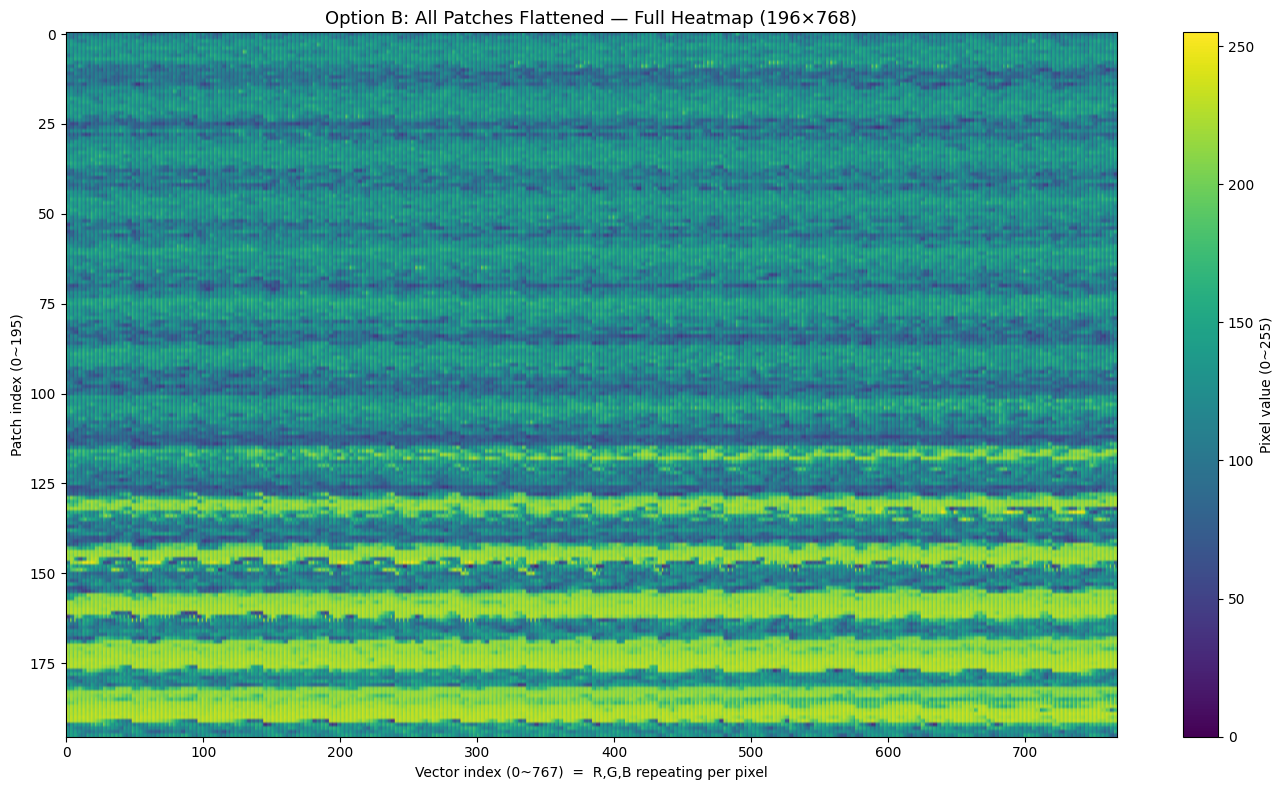

In [9]:
# Option B: Full heatmap (196 patches × 768 values)
patches_np_raw = np.array([p.flatten() for p in patches], dtype=np.float32)  # (196, 768)

plt.figure(figsize=(14, 8))
plt.imshow(patches_np_raw, aspect='auto', cmap='viridis', vmin=0, vmax=255)
plt.colorbar(label='Pixel value (0~255)')
plt.title('Option B: All Patches Flattened — Full Heatmap (196×768)', fontsize=13)
plt.xlabel('Vector index (0~767)  =  R,G,B repeating per pixel')
plt.ylabel('Patch index (0~195)')
plt.tight_layout()
plt.show()